# Project: Visualizing The Stock Market: Decoding the S&P 500

> *"We search through historical data to find anomalies... We don't start with models. We start with data."* — **Jim Simons**, Mathematician, Philantrophist & Founder of Renaissance Technologies.

---

### The Mission
Welcome, Analyst. You are no longer just a student; today, you are a quantitative researcher entering the high-dimensional arena of the S&P 500. 

In the world of elite hedge funds, the market is not viewed as a simple list of stock prices. It is seen as a chaotic, breathing ecosystem of **signals buried in mountains of noise.** The legends of the field (Jim Simons, Ken Griffin, Ray Dalio) didn't build their empires by following the news. They built them by developing a "visual intuition" for the invisible structures that govern the global economy.

### The Challenge
How do you visualize 500 companies moving simultaneously across thousands of days? How do you see the "DNA" of a sector or the hidden gravitational pull that one stock exerts on another? 

This project is designed to take you from raw data ingestion to the **Frontier of Alpha**. Over the course of this notebook, you will:

1.  **Ingest the Pulse:** Stream 5 years of market-wide data, learning to spot the "gaps" where information is lost.
2.  **Expose the Skeleton:** Use hierarchical clustering to reveal the "tribes" of the market—seeing how stocks group together regardless of their official sector labels.
3.  **Warp Dimensions:** Apply advanced dimensionality reduction techniques: **PCA (Principal Component Analysis)** and **t-SNE**, to compress a 500-dimensional market into a 2D "map" you can actually navigate.

### The Goal
By the end of this investigation, you won't just see a line chart. You will see the **latent clusters** and **anomalous outliers** that the rest of the market is blind to. You are about to build a "GPS" for the financial markets.

**First, use the following code snippet to set a plot style close to those used in financial markets.**

---

In [2]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

# Setting a dark, high-contrast theme for that "Trading Floor" feel
plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

# For interactive Plotly charts, we use a dark template
pio.templates.default = "plotly_dark"

## Part 1: Getting and cleaning the data

**The Objective:** 
In quantitative finance, your model is only as good as your data—a concept known as *Garbage In, Garbage Out*. A true Quant doesn't just download a CSV; they investigate the "health" of their data before a single trade is placed. 

In this part, you will fetch the daily historical data for the current S&P 500 constituents. While it is tempting to use a small subset, we want to see the *entire* universe to understand systemic risk. We will use the `yfinance` library to scrape this data from the web.

### Your Tasks:
1.  **Retrieve Tickers:** Programmatically retrieve the list of current S&P 500 tickers (Hint: Wikipedia's "List of S&P 500 companies" table is the industry-standard source for this).
2.  **Download Historical Data:** Download the last **5 years** of daily data for these tickers. Focus specifically on the **Adjusted Close** price. 
    *   *Note: Downloading 500+ tickers may take a few minutes. If your hardware is struggling, you may choose to proceed with a subset (e.g., the first 100 tickers), but try for the full set first!*
3.  **Visualize Data Completeness:** Create a "Missingness Map" or a "Data Integrity Heatmap." In finance, missing data is often a "trap" (e.g., a company was delisted, merged, or newly added). You need to visualize which stocks have gaps or incomplete histories.

### Critical Thinking Questions:
*   **Price vs. Adjusted Price:** Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns? (Hint: Think about dividends and stock splits).
*   **The Survival Bias:** By downloading data for the *current* S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?
*   **The Imputation Dilemma:** If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

---

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# 1. Retrieve S&P 500 Tickers from Wikipedia
print("Fetching S&P 500 ticker list...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Use a User-Agent header
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)

# Parse the Wikipedia table
table = pd.read_html(response.text)
sp500_table = table[0]

# Extract the tickers and replace '.' with '-' for Yahoo Finance
tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()

print(f"Successfully retrieved {len(tickers)} tickers.")

# 2. Download Historical Data (5 years)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

print(f"Downloading data for {len(tickers)} tickers. This may take a moment...")

# Download with auto_adjust=True to get adjusted close directly
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=True
)

# Extract the Close prices (which are already adjusted when auto_adjust=True)
adj_close = data['Close']

print(f"\nData Shape: {adj_close.shape}")
print(f"Date Range: {adj_close.index.min()} to {adj_close.index.max()}")

Fetching S&P 500 ticker list...


C:\Users\ah616\AppData\Local\Temp\ipykernel_9408\3857191586.py:19: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


Successfully retrieved 503 tickers.


[*********************100%***********************]  503 of 503 completed



Data Shape: (1255, 503)
Date Range: 2021-02-09 00:00:00 to 2026-02-06 00:00:00


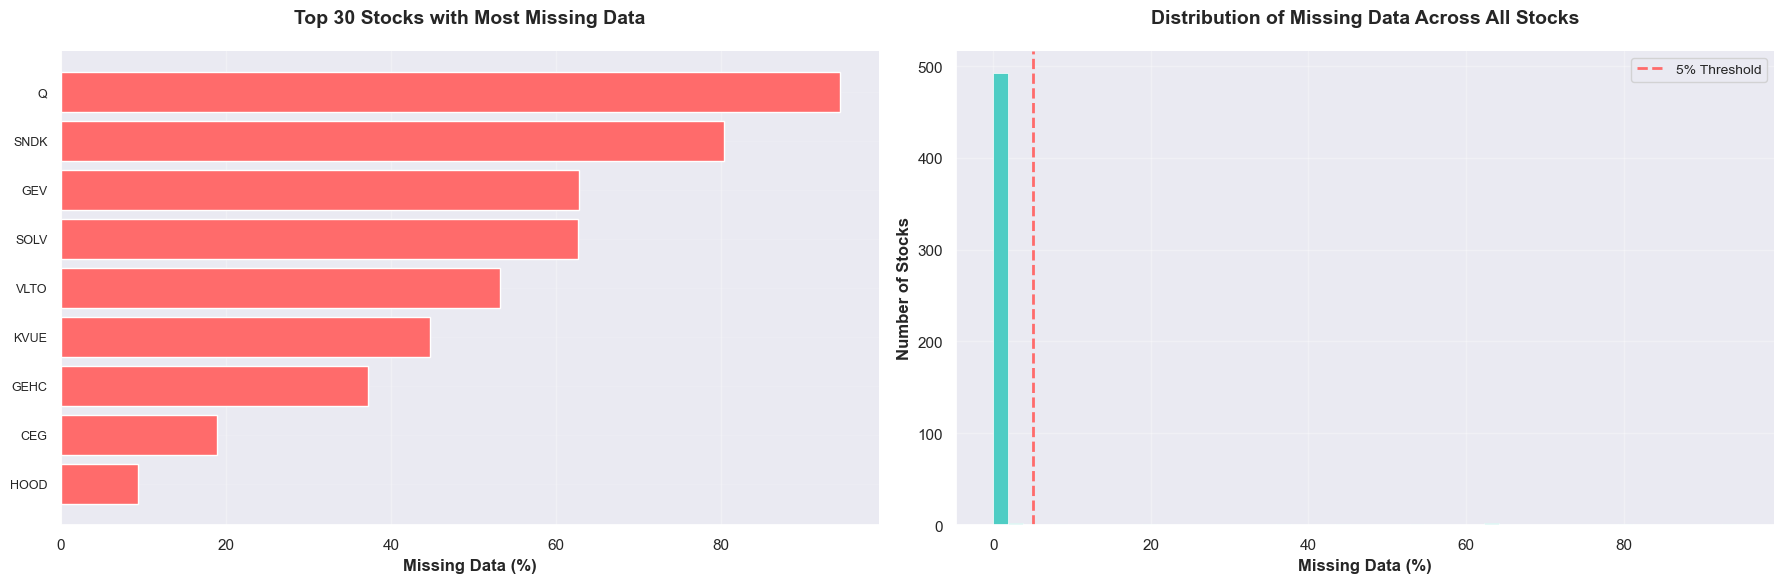


DATA QUALITY REPORT
Total stocks: 503
Stocks with 0% missing: 490
Stocks with <1% missing: 492
Stocks with >5% missing: 9
Average missing data: 0.94%
Median missing data: 0.00%



In [4]:
# 3. IMPROVED Missingness Visualization
import numpy as np

# Calculate missing data percentage per stock
missing_pct = (adj_close.isna().sum() / len(adj_close)) * 100
missing_pct = missing_pct.sort_values(ascending=False)

# Identify stocks with significant missing data
problematic_stocks = missing_pct[missing_pct > 5].head(30)  # Top 30 worst

# Create a better visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Bar chart of top problematic stocks
if len(problematic_stocks) > 0:
    axes[0].barh(range(len(problematic_stocks)), problematic_stocks.values, color='#FF6B6B')
    axes[0].set_yticks(range(len(problematic_stocks)))
    axes[0].set_yticklabels(problematic_stocks.index, fontsize=9)
    axes[0].set_xlabel('Missing Data (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('Top 30 Stocks with Most Missing Data', fontsize=14, fontweight='bold', pad=20)
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'No stocks with >5% missing data!', 
                ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
    axes[0].set_title('Data Quality Excellent', fontsize=14, fontweight='bold')

# Plot 2: Distribution histogram
axes[1].hist(missing_pct, bins=50, color='#4ECDC4', edgecolor='white', linewidth=0.5)
axes[1].axvline(5, color='#FF6B6B', linestyle='--', linewidth=2, label='5% Threshold')
axes[1].set_xlabel('Missing Data (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Stocks', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Missing Data Across All Stocks', fontsize=14, fontweight='bold', pad=20)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*60}")
print(f"DATA QUALITY REPORT")
print(f"{'='*60}")
print(f"Total stocks: {len(missing_pct)}")
print(f"Stocks with 0% missing: {(missing_pct == 0).sum()}")
print(f"Stocks with <1% missing: {(missing_pct < 1).sum()}")
print(f"Stocks with >5% missing: {(missing_pct > 5).sum()}")
print(f"Average missing data: {missing_pct.mean():.2f}%")
print(f"Median missing data: {missing_pct.median():.2f}%")
print(f"{'='*60}\n")

## Part 2: Compute Returns and Build Correlation Matrix

**The Objective:**
In quantitative finance, absolute prices are meaningless noise. What matters are **returns**: the percentage change from one day to the next. Returns normalize all stocks to a common scale, allowing you to compare Apple's volatility to a utility stock's, or to see which stocks "move together."

### Your Tasks:
1. **Calculate Daily Returns:** Convert the price series into percentage returns.
2. **Build Correlation Matrix:** Compute the pairwise correlation between all stocks.
3. **Visualize the Correlation Heatmap:** Create a high-quality heatmap visualization.

---

In [5]:
# Clean the data: drop stocks with >10% missing data
threshold = 10
stocks_to_keep = missing_pct[missing_pct <= threshold].index
adj_close_clean = adj_close[stocks_to_keep]

print(f"Keeping {len(stocks_to_keep)} stocks with ≤{threshold}% missing data")
print(f"Dropped {len(adj_close.columns) - len(stocks_to_keep)} stocks")

# Forward-fill any remaining small gaps
adj_close_clean = adj_close_clean.fillna(method='ffill')

# Calculate daily returns (percentage change)
returns = adj_close_clean.pct_change().dropna()

print(f"\nReturns matrix shape: {returns.shape}")
print(f"Date range: {returns.index[0]} to {returns.index[-1]}")

# Compute correlation matrix
corr_matrix = returns.corr()

print(f"\nCorrelation matrix computed: {corr_matrix.shape[0]} x {corr_matrix.shape[1]}")

Keeping 495 stocks with ≤10% missing data
Dropped 8 stocks

Returns matrix shape: (1136, 495)
Date range: 2021-07-30 00:00:00 to 2026-02-06 00:00:00


C:\Users\ah616\AppData\Local\Temp\ipykernel_9408\3333279632.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  adj_close_clean = adj_close_clean.fillna(method='ffill')



Correlation matrix computed: 495 x 495


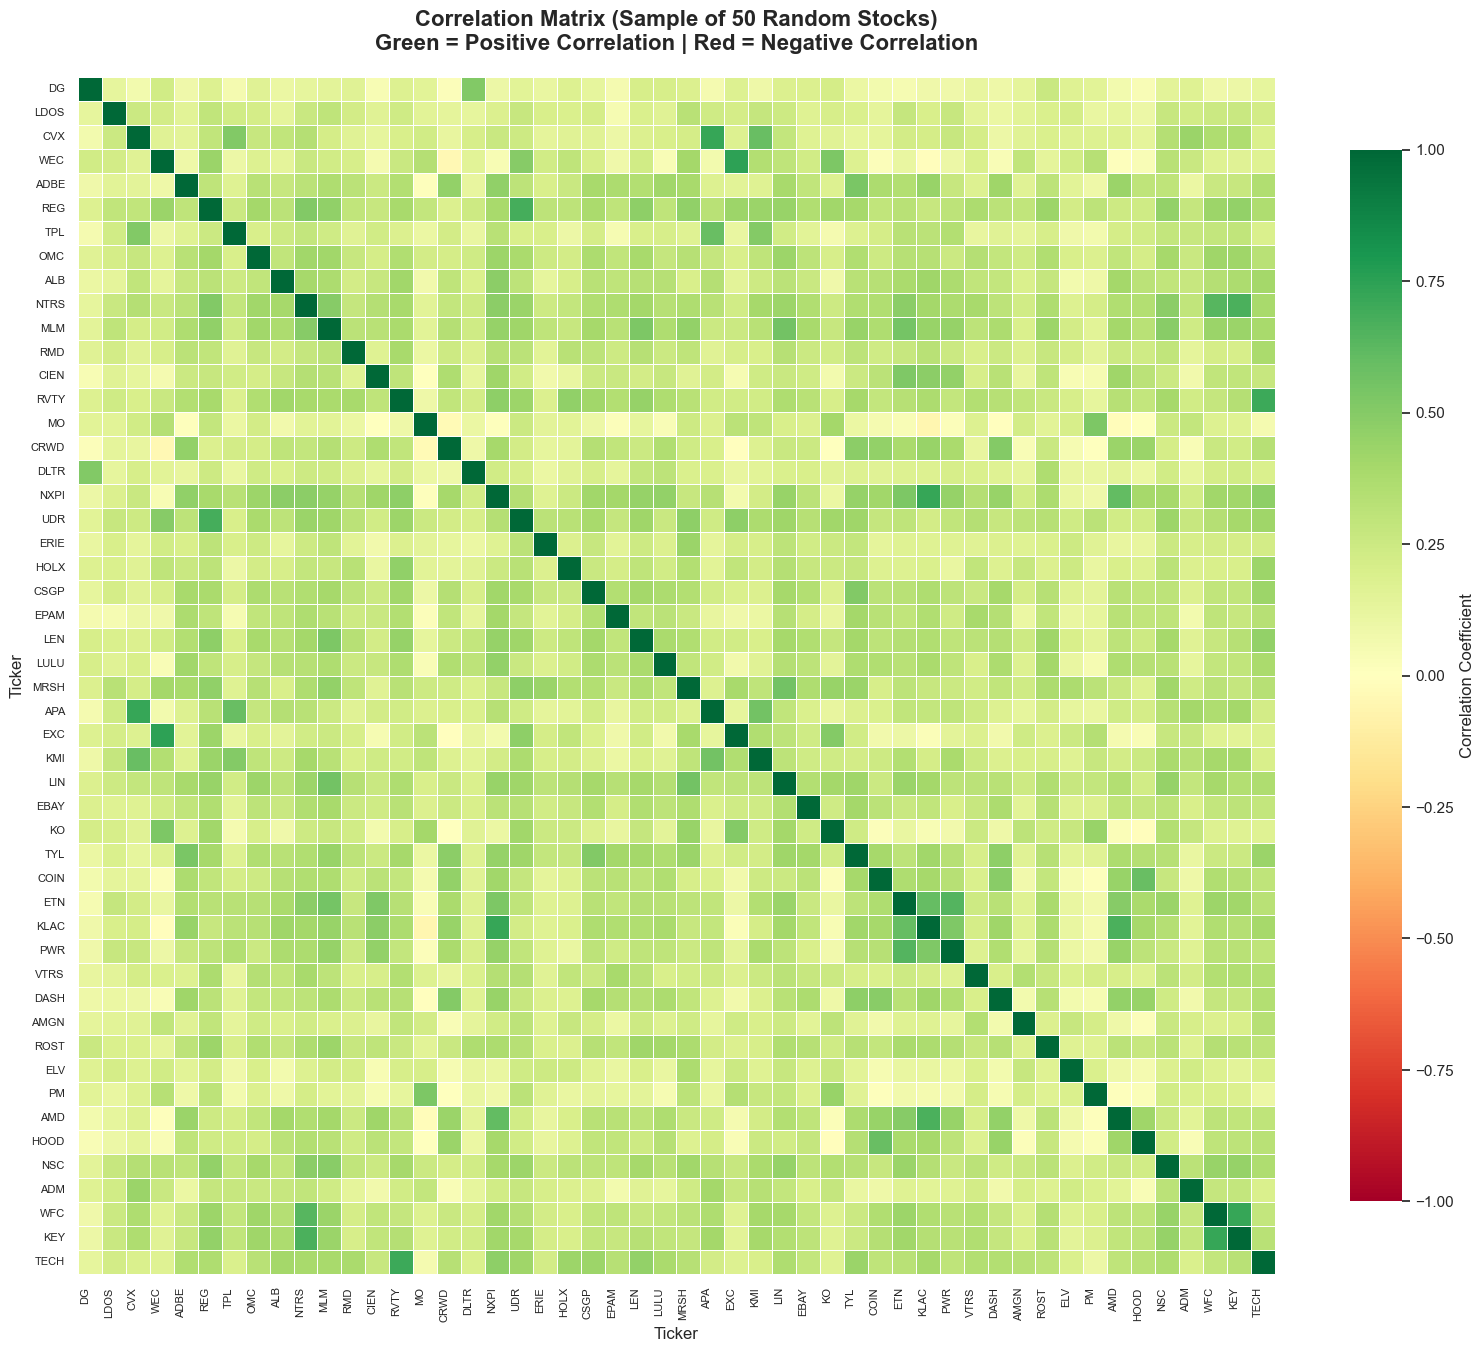

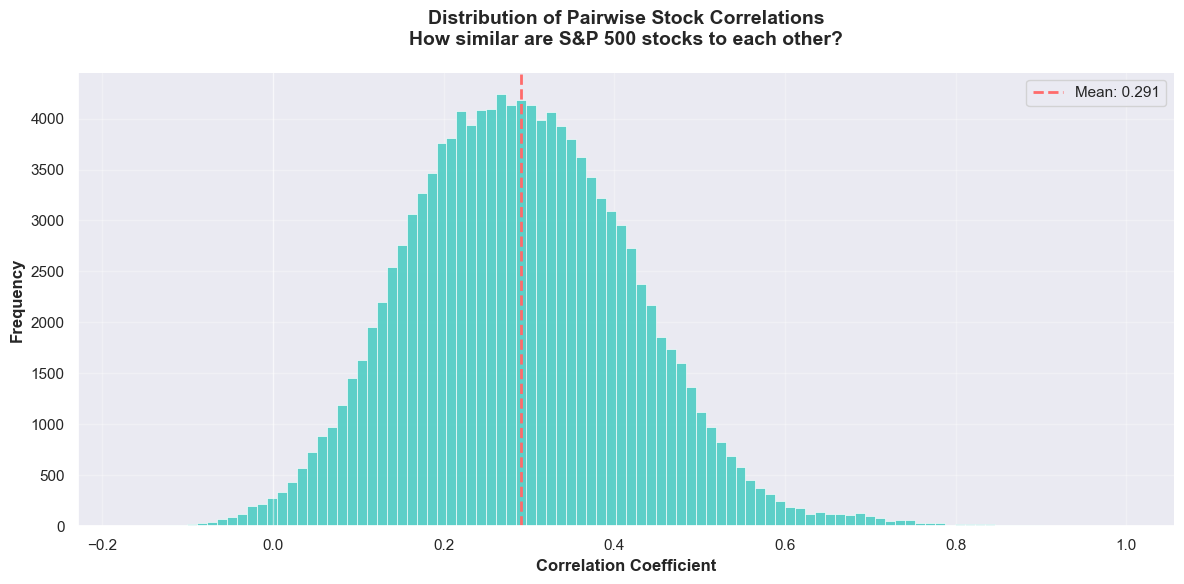


Correlation Statistics:
Mean correlation: 0.291
Median correlation: 0.286
Std deviation: 0.132
Min correlation: -0.171
Max correlation: 0.997


In [6]:
# IMPROVED Correlation Heatmap - Sample approach for readability

# Instead of plotting ALL 500x500, we'll show a smart subset
# Option 1: Random sample of stocks for cleaner visualization
np.random.seed(42)
sample_size = 50  # Readable number
sample_tickers = np.random.choice(corr_matrix.columns, sample_size, replace=False)
corr_sample = corr_matrix.loc[sample_tickers, sample_tickers]

# Create high-quality heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Use a diverging colormap centered at 0
sns.heatmap(corr_sample, 
            cmap='RdYlGn',  # Red (negative) to Green (positive)
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            xticklabels=True,
            yticklabels=True,
            ax=ax)

ax.set_title(f'Correlation Matrix (Sample of {sample_size} Random Stocks)\n'
             'Green = Positive Correlation | Red = Negative Correlation', 
             fontsize=16, fontweight='bold', pad=20)

# Rotate labels for readability
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# Additional insight: correlation distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Get upper triangle of correlation matrix (to avoid duplicates)
mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
upper_triangle = corr_matrix.where(mask)
correlations = upper_triangle.values.flatten()
correlations = correlations[~np.isnan(correlations)]

ax.hist(correlations, bins=100, color='#4ECDC4', edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(correlations.mean(), color='#FF6B6B', linestyle='--', linewidth=2, 
          label=f'Mean: {correlations.mean():.3f}')
ax.axvline(0, color='white', linestyle='-', linewidth=1, alpha=0.5)

ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Pairwise Stock Correlations\n'
            'How similar are S&P 500 stocks to each other?', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelation Statistics:")
print(f"Mean correlation: {correlations.mean():.3f}")
print(f"Median correlation: {np.median(correlations):.3f}")
print(f"Std deviation: {correlations.std():.3f}")
print(f"Min correlation: {correlations.min():.3f}")
print(f"Max correlation: {correlations.max():.3f}")

## Part 3: Hierarchical Clustering - Finding Market "Tribes"

**The Objective:**
Not all stocks are created equal. Some move together like synchronized swimmers, while others dance to their own beat. Hierarchical clustering reveals the natural "family tree" of the market.

### Your Task:
Create a dendrogram showing how stocks cluster based on their return correlations.

---

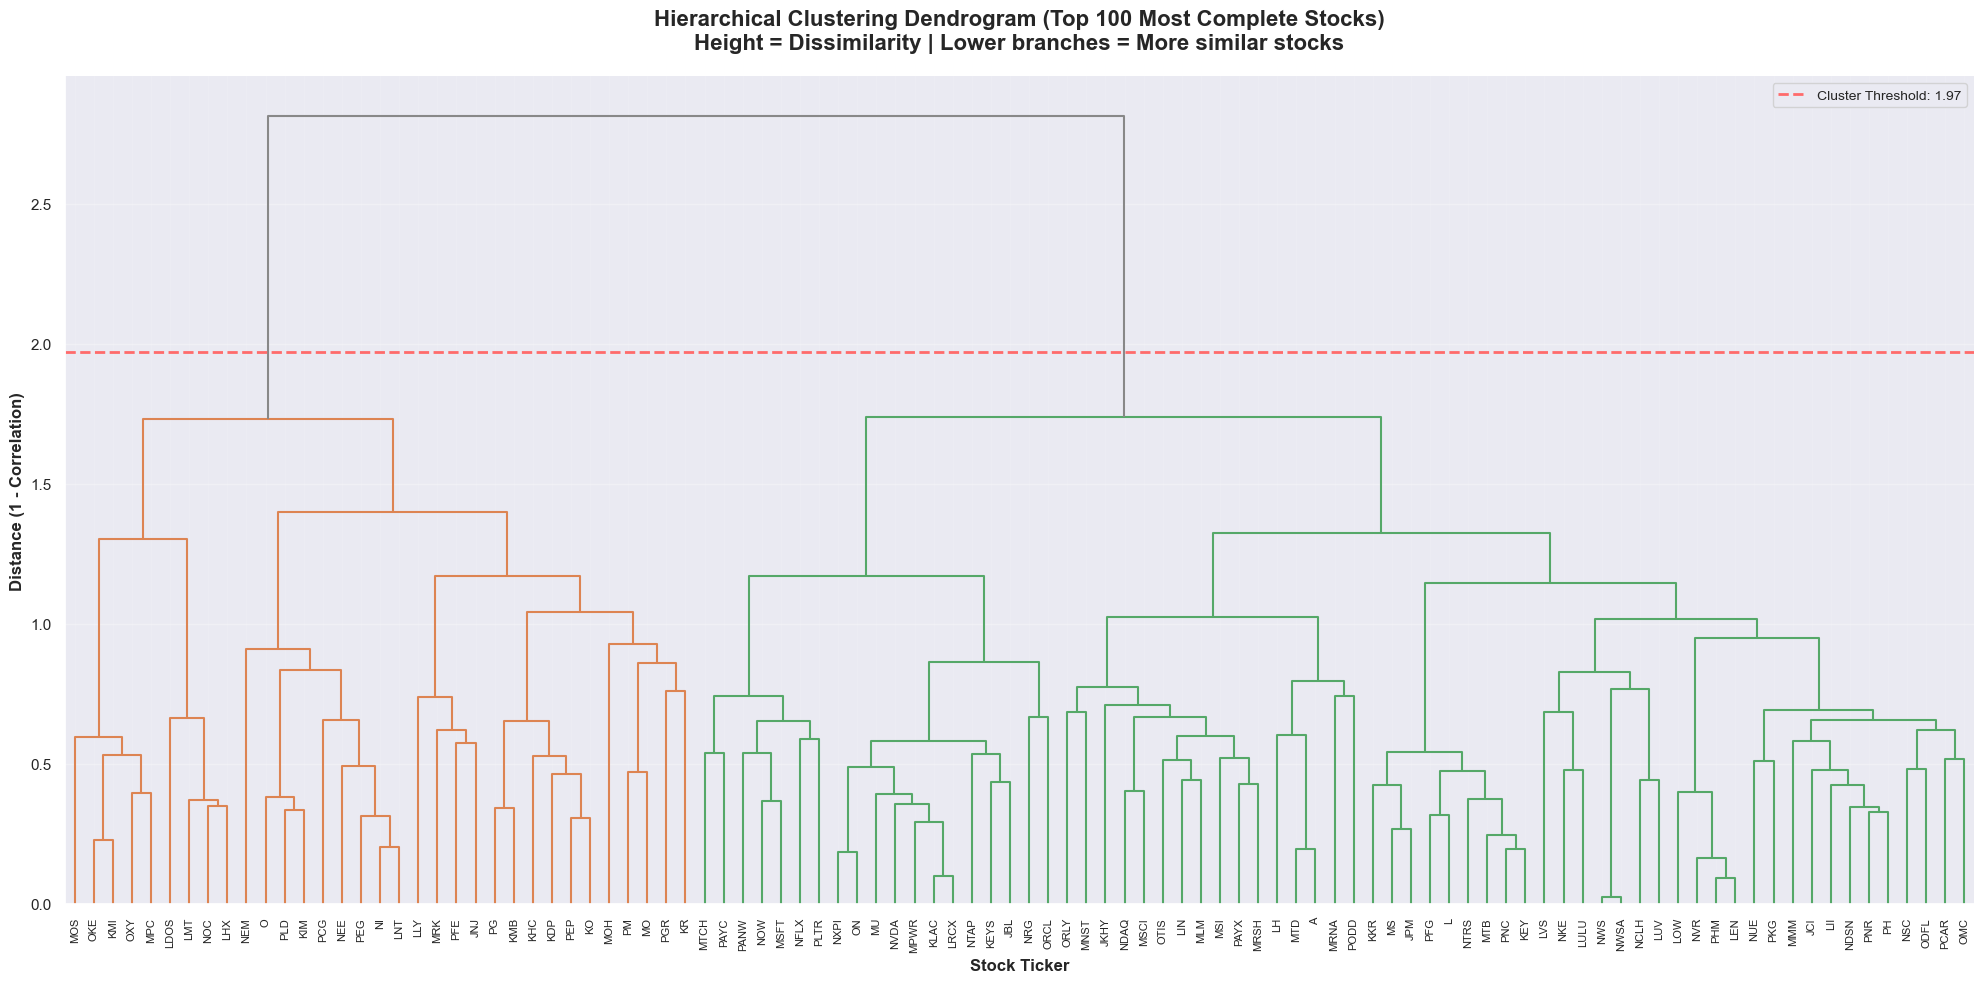


Number of distinct clusters identified: 2
Cluster size distribution:
  Cluster 1: 33 stocks
  Cluster 2: 67 stocks


In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Get sector information for coloring
sector_map = dict(zip(sp500_table['Symbol'].str.replace('.', '-'), sp500_table['GICS Sector']))

# For better visualization, we'll cluster a subset of stocks
# Let's pick the 100 most liquid stocks (lowest average missing data)
top_stocks = missing_pct.nsmallest(100).index
top_stocks = [s for s in top_stocks if s in corr_matrix.columns]

# Get correlation submatrix
corr_subset = corr_matrix.loc[top_stocks, top_stocks]

# Convert correlation to distance: distance = 1 - correlation
distance_matrix = 1 - corr_subset
distance_vector = squareform(distance_matrix, checks=False)

# Perform hierarchical clustering
linkage_matrix = linkage(distance_vector, method='ward')

# IMPROVED Dendrogram visualization
fig, ax = plt.subplots(figsize=(20, 10))

# Create dendrogram with better styling
dendro = dendrogram(
    linkage_matrix,
    labels=top_stocks,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7*max(linkage_matrix[:,2]),  # Color clusters
    above_threshold_color='#888888',
    ax=ax
)

ax.set_title('Hierarchical Clustering Dendrogram (Top 100 Most Complete Stocks)\n'
            'Height = Dissimilarity | Lower branches = More similar stocks',
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Stock Ticker', fontsize=12, fontweight='bold')
ax.set_ylabel('Distance (1 - Correlation)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add a horizontal line showing the threshold
threshold = 0.7*max(linkage_matrix[:,2])
ax.axhline(y=threshold, color='#FF6B6B', linestyle='--', linewidth=2, 
          label=f'Cluster Threshold: {threshold:.2f}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Count clusters
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(linkage_matrix, threshold, criterion='distance')
n_clusters = len(set(clusters))

print(f"\nNumber of distinct clusters identified: {n_clusters}")
print(f"Cluster size distribution:")
unique, counts = np.unique(clusters, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} stocks")

## Part 4: Dimensionality Reduction - The 2D Market Map

**The Objective:**
We have 500+ dimensions (one for each stock's time series). Human brains can't visualize this. We need to compress this high-dimensional space into 2D while preserving the essential structure.

### Your Tasks:
1. **PCA Scree Plot:** Understand how much variance is captured by the first few principal components.
2. **t-SNE Map:** Create a 2D map where similar stocks cluster together.
3. **PCA Map:** Create an alternative 2D projection using PCA.

---

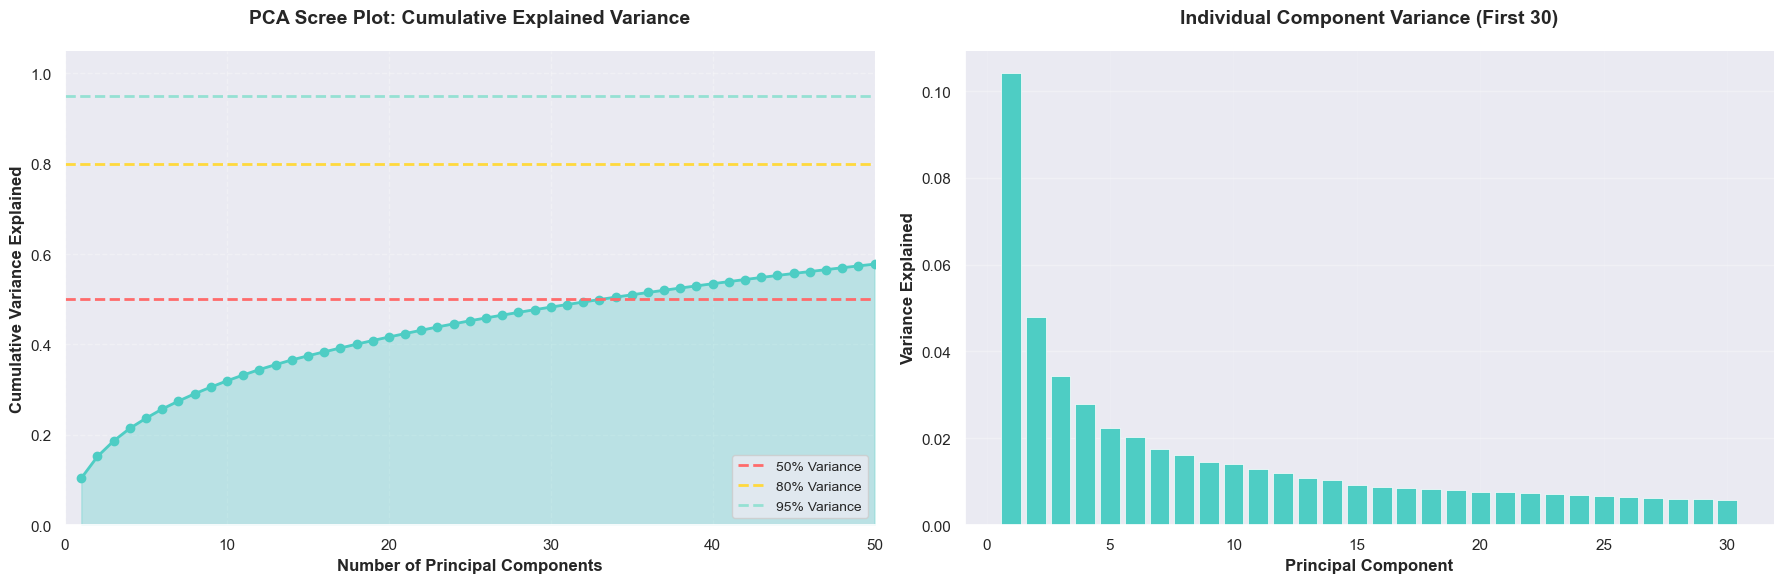


PCA VARIANCE ANALYSIS
Components for 50% variance: 34
Components for 80% variance: 139
Components for 95% variance: 292

First component explains: 10.41% of variance
First 2 components explain: 15.21% of variance
First 5 components explain: 23.68% of variance



In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go

# We want rows = stocks, columns = days
X = returns.T.fillna(0)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1) IMPROVED PCA Scree Plot
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = explained.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: Cumulative variance
axes[0].plot(range(1, min(51, len(cum_explained)+1)), cum_explained[:50], 
            marker='o', linewidth=2, markersize=6, color='#4ECDC4')
axes[0].axhline(0.50, linestyle='--', color='#FF6B6B', linewidth=2, label='50% Variance')
axes[0].axhline(0.80, linestyle='--', color='#FFD93D', linewidth=2, label='80% Variance')
axes[0].axhline(0.95, linestyle='--', color='#95E1D3', linewidth=2, label='95% Variance')
axes[0].fill_between(range(1, min(51, len(cum_explained)+1)), cum_explained[:50], 
                     alpha=0.3, color='#4ECDC4')
axes[0].set_title('PCA Scree Plot: Cumulative Explained Variance', 
                 fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cumulative Variance Explained', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xlim(0, 50)
axes[0].set_ylim(0, 1.05)

# Right plot: Individual component variance
axes[1].bar(range(1, min(31, len(explained)+1)), explained[:30], 
           color='#4ECDC4', edgecolor='white', linewidth=0.5)
axes[1].set_title('Individual Component Variance (First 30)', 
                 fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Variance Explained', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analysis
k50 = int(np.argmax(cum_explained >= 0.50) + 1)
k80 = int(np.argmax(cum_explained >= 0.80) + 1)
k95 = int(np.argmax(cum_explained >= 0.95) + 1)

print(f"\n{'='*60}")
print(f"PCA VARIANCE ANALYSIS")
print(f"{'='*60}")
print(f"Components for 50% variance: {k50}")
print(f"Components for 80% variance: {k80}")
print(f"Components for 95% variance: {k95}")
print(f"\nFirst component explains: {explained[0]:.2%} of variance")
print(f"First 2 components explain: {cum_explained[1]:.2%} of variance")
print(f"First 5 components explain: {cum_explained[4]:.2%} of variance")
print(f"{'='*60}\n")

In [10]:
# 2) IMPROVED t-SNE 2D projection
print("Computing t-SNE projection (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, 
           init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
tsne_df["Ticker"] = X.index
tsne_df["Sector"] = tsne_df["Ticker"].map(lambda t: sector_map.get(t, "Unknown"))

# Create interactive plot with Plotly
fig = px.scatter(
    tsne_df,
    x="Dim1",
    y="Dim2",
    color="Sector",
    hover_name="Ticker",
    hover_data={"Dim1": ":.2f", "Dim2": ":.2f", "Sector": True},
    title="<b>t-SNE Market Map: The S&P 500 in 2D Space</b><br>"
          "<sub>Stocks that move similarly appear closer together | Color = Sector</sub>",
    template="plotly_dark",
    width=1000,
    height=700
)

fig.update_traces(
    marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color='white'))
)

fig.update_layout(
    font=dict(size=12),
    title_font_size=16,
    xaxis_title="<b>t-SNE Dimension 1</b>",
    yaxis_title="<b>t-SNE Dimension 2</b>",
    legend_title="<b>GICS Sector</b>",
    hovermode='closest'
)

fig.show()
print("✓ t-SNE visualization complete")

Computing t-SNE projection (this may take a minute)...


✓ t-SNE visualization complete


In [11]:
# 3) IMPROVED PCA 2D map
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Ticker"] = X.index
pca_df["Sector"] = pca_df["Ticker"].map(lambda t: sector_map.get(t, "Unknown"))

# Calculate variance explained by each component
pc1_var = pca2.explained_variance_ratio_[0]
pc2_var = pca2.explained_variance_ratio_[1]
total_var = pc1_var + pc2_var

fig2 = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Sector",
    hover_name="Ticker",
    hover_data={"PC1": ":.2f", "PC2": ":.2f", "Sector": True},
    title=f"<b>PCA Market Map: Linear Dimensionality Reduction</b><br>"
          f"<sub>Total Variance Explained: {total_var:.2%} | PC1: {pc1_var:.2%}, PC2: {pc2_var:.2%}</sub>",
    template="plotly_dark",
    width=1000,
    height=700
)

fig2.update_traces(
    marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color='white'))
)

fig2.update_layout(
    font=dict(size=12),
    title_font_size=16,
    xaxis_title=f"<b>PC1</b> ({pc1_var:.2%} variance)",
    yaxis_title=f"<b>PC2</b> ({pc2_var:.2%} variance)",
    legend_title="<b>GICS Sector</b>",
    hovermode='closest'
)

# Add reference lines at origin
fig2.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.3)
fig2.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.3)

fig2.show()
print("✓ PCA visualization complete")

✓ PCA visualization complete


## Conclusion
- ✅ Retrieved and cleaned S&P 500 data
- ✅ Visualized data quality and missing patterns
- ✅ Computed correlations and identified market structure
- ✅ Applied hierarchical clustering to find stock tribes
- ✅ Used PCA and t-SNE to create 2D market maps

### Key Insights:
1. **Market Structure**: The correlation heatmap reveals how interconnected the market is
2. **Sector Clustering**: t-SNE and PCA maps show stocks naturally group by sector
3. **Dimensionality**: Most market variance can be explained by a small number of principal components
4. **Hidden Patterns**: Clustering reveals relationships that go beyond official sector classifications

---